In [1]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
import pandas as pd

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv")
y_test = pd.read_csv("../data/processed/y_test.csv")

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (80, 4)
X_test shape : (20, 4)
y_train shape: (80, 1)
y_test shape : (20, 1)


In [3]:
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

y_train shape: (80,)
y_test shape : (20,)


In [4]:
tscv = TimeSeriesSplit(n_splits=3)

print(tscv)

TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None)


In [5]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

print(param_grid)

{'n_estimators': [50, 100, 200], 'max_depth': [3, 5, 10], 'min_samples_leaf': [1, 2, 4]}


In [6]:
rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

In [7]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1
)

In [8]:
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 27 candidates, totalling 81 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sp

In [9]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV Score (MAE):")
print(-grid_search.best_score_)

Best Parameters:
{'max_depth': 3, 'min_samples_leaf': 1, 'n_estimators': 100}

Best CV Score (MAE):
0.5796651505051534


In [10]:
best_rf = grid_search.best_estimator_

print(best_rf)

RandomForestRegressor(max_depth=3, n_jobs=-1, random_state=42)


In [11]:
y_pred = best_rf.predict(X_test)

In [12]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Test MAE :", mae)
print("Test RMSE:", rmse)
print("Test R²  :", r2)

Test MAE : 0.8335666470299483
Test RMSE: 0.9678580054860406
Test R²  : -0.152984430890309


In [17]:
import joblib

joblib.dump(model, "../models/champion.joblib")

print("Champion model saved successfully.")

NameError: name 'model' is not defined

In [18]:
print(type(best_rf))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
model = LinearRegression()

model.fit(X_train_scaled, y_train)

print("Linear Regression trained successfully.")

Linear Regression trained successfully.


In [22]:
import joblib

joblib.dump(model, "../models/champion.joblib")

print("Champion model saved successfully.")

Champion model saved successfully.


In [23]:
import json

with open("../models/rf_best_params.json", "w") as f:
    json.dump(grid_search.best_params_, f, indent=4)

print("Best parameters saved successfully.")

Best parameters saved successfully.


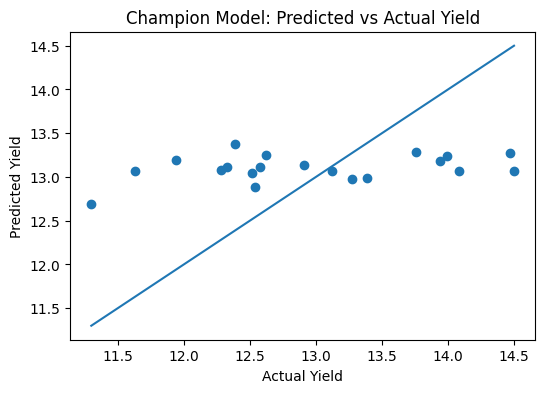

In [24]:
import matplotlib.pyplot as plt

y_pred_lr = model.predict(X_test_scaled)

plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred_lr)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Champion Model: Predicted vs Actual Yield")

plt.show()

In [25]:
import os

print(os.listdir("../models"))

['.gitkeep', 'champion.joblib', 'linear_regression.joblib', 'random_forest.joblib', 'rf_best_params.json', 'scaler.joblib']
